# mplfinance vs mplchart

[mplfinance](https://github.com/matplotlib/mplfinance) is the matplotlib project's finance plotting library — mature, feature-rich, and widely used. mplchart is a younger library with a different design center: declarative chart composition with built-in indicators, on pandas or polars data. Both render classic financial charts with matplotlib, so they embed anywhere matplotlib does — scripts, notebooks, GUI apps, saved images.

This page compares the two honestly, with the same chart built in each. If you want a mature, stable API today, mplfinance is the safe choice — mplchart is experimental and its interface is still evolving.

In [1]:
import mplfinance as mpf

from mplchart.chart import Chart
from mplchart.primitives import Candlesticks, Volume
from mplchart.indicators import SMA
from mplchart.samples import sample_prices

prices = sample_prices()                                 # lower-case columns, full history
data = prices.tail(250).rename(columns=str.capitalize)   # mplfinance wants Capitalized columns
prices.tail(3)

,open,high,low,close,volume
date,,,,,
2025-11-13,274.109985,276.700012,272.089996,272.950012,49602800
2025-11-14,271.049988,275.959991,269.600006,272.410004,47399300
2025-11-17,268.815002,270.489990,265.730011,267.459991,42862157


## The same chart in both

Candlesticks, volume, and two moving averages — first mplfinance, then mplchart.

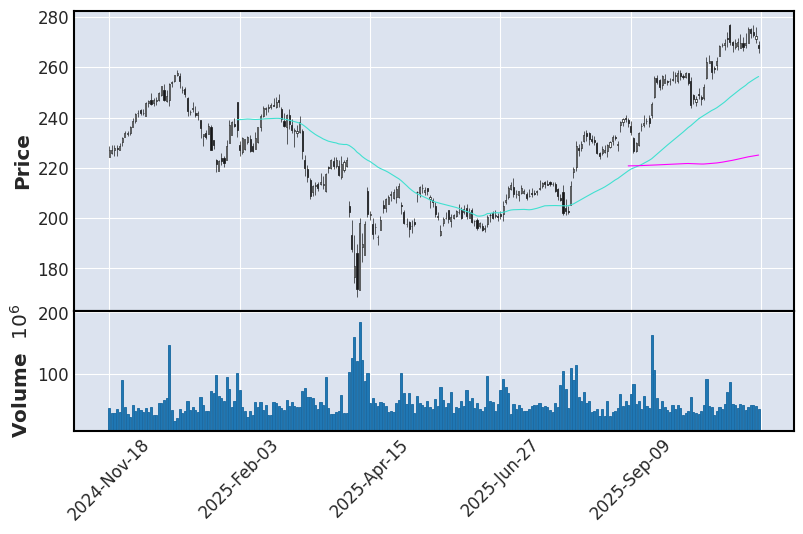

In [2]:
mpf.plot(data, type="candle", mav=(50, 200), volume=True, figsize=(10, 6))

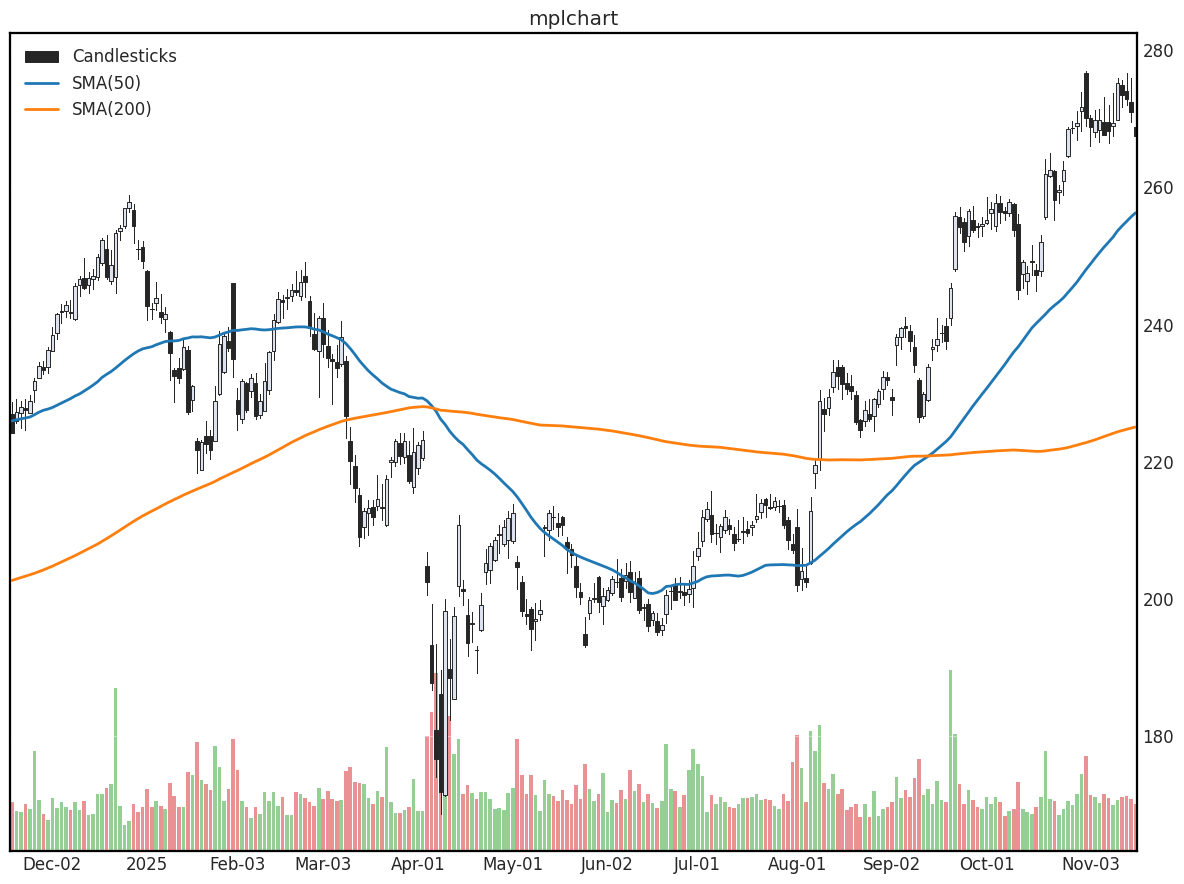

In [3]:
Chart(prices, title="mplchart", max_bars=250).plot(
    Candlesticks(), Volume(), SMA(50), SMA(200),
).show()

Same ingredients, two API styles: mplfinance is *option-driven* — one `mpf.plot(...)` call configured through keyword arguments (`type=`, `mav=`, `volume=`). mplchart is *composition-driven* — a chart is a list of primitives and indicators, extended by adding items or panes.

One subtle difference visible above: `mav=(50, 200)` computes over the data you pass in, so on a 250-bar slice the 200-bar average only exists for the last 50 bars. mplchart computes indicators over the full history and *then* windows to `max_bars`, so both averages are complete across the visible range.

## Data conventions

| | mplfinance | mplchart |
|---|---|---|
| Backend | pandas | pandas **or polars** |
| Columns | `Open`, `High`, `Low`, `Close`, `Volume` (capitalized) | `open`, `high`, `low`, `close`, `volume` (lower case) |
| Dates | `DatetimeIndex` | datetime index (pandas) or `date`/`datetime` column |
| Mismatched names | rename yourself | `Chart(..., normalize=True)` |

The polars support is a real differentiator if your pipeline is polars-based: mplchart consumes polars frames natively (with polars expressions instead of indicators — see the backends article), no conversion to pandas needed.

## Non-trading gaps

Both libraries can draw price history without weekend and holiday gaps, via different mechanisms. mplfinance controls it with a flag — `show_nontrading=False` is the default, and passing `True` restores calendar spacing. mplchart eliminates gaps *by construction*: bars are positioned by row number and the date axis maps tick labels back to dates, so gapless is the default; `Chart(..., raw_dates=True)` opts into raw calendar spacing instead.

## Chart types

This is mplfinance's strongest suit. Beyond `type="candle"` it renders `ohlc`, `line`, `hollow_and_filled`, and — notably — the box-based chart types: **Renko** and **Point & Figure**, which resample price movement into bricks/boxes independent of time. mplchart covers the time-series types (`Candlesticks`, `OHLC`, line/area/bar plots) but has no Renko or PnF.

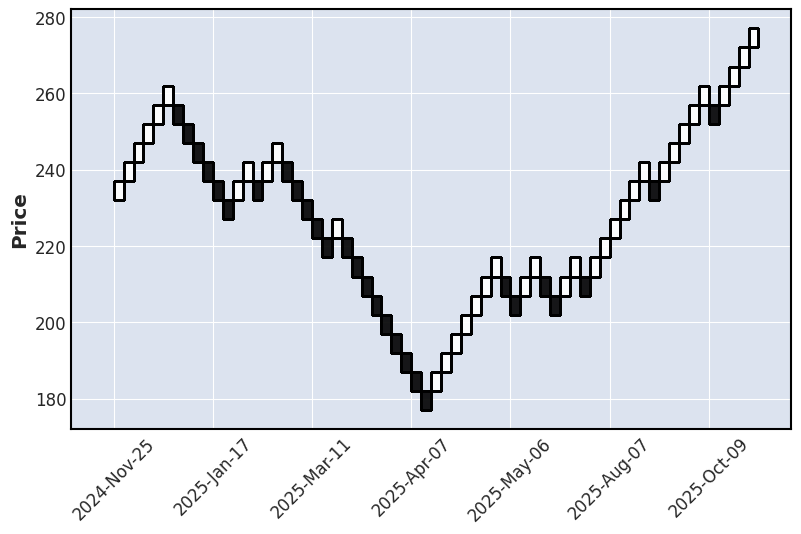

In [4]:
mpf.plot(data, type="renko", renko_params=dict(brick_size=5), figsize=(10, 6))

## Indicators

mplfinance ships moving averages (`mav=`, `ema=`) built in; anything else you compute yourself and attach with `mpf.make_addplot(...)`, which gives full control at the cost of manual wiring. mplchart ships a library of indicators (`RSI`, `MACD`, `BBANDS`, ATR-family, and more) that slot directly into the chart with automatic panes, plus polars expression equivalents, condition primitives (`Stripes`, `Markers`), and support for custom callables. If your charts are indicator-heavy, this is where the declarative style pays off.

## Styling

mplfinance has its own style system with a few dozen named presets (`yahoo`, `charles`, `binance`, `blueskies`, ...) plus `make_mpf_style` for custom ones. mplchart stays closer to stock matplotlib: standard matplotlib styles apply, with chart-level options (`colorup`/`colordn`, color schemes) for the finance-specific parts.

## Choosing

Reach for **mplfinance** when you want a mature, stable library, the box-based chart types (Renko, PnF), or its preset style gallery. Reach for **mplchart** when your charts are indicator-heavy and declarative composition fits your code, or when your data lives in polars. Both render through matplotlib, so either embeds wherever matplotlib does — but that is where the overlap ends: the two APIs share nothing, so switching libraries means rewriting your chart code, not tweaking it.